``ModelEvaluatorPlot.learning_curve`` draws one metric versus training size from ``ModelEvaluator.learning_curve``, one line per model with a shaded bootstrap confidence band. First, the dataset, feature matrix, and learning curve:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + a small feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix X
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

me = aa.ModelEvaluator(models=["rf", "log_reg"], random_state=42, verbose=False)
df_curve = me.learning_curve(X, labels, train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0], n_rounds=3,
                             metrics=["balanced_accuracy", "mcc"])

Plot ``df_curve`` for a chosen ``metric`` (default ``mcc``) with a ``figsize`` and per-model ``colors``:

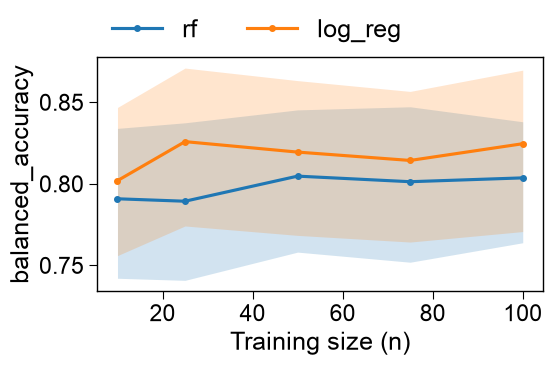

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
fig, ax = aa.ModelEvaluatorPlot.learning_curve(df_curve=df_curve, metric="balanced_accuracy",
                                               figsize=(6, 4), colors=["tab:blue", "tab:orange"])
plt.tight_layout()
plt.show()

Set ``show_ci=False`` to draw only the mean curves:

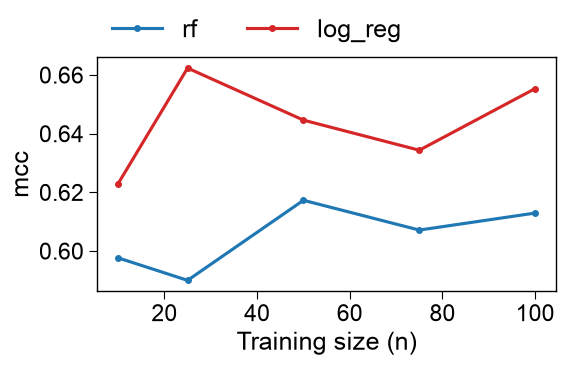

In [3]:
fig, ax = aa.ModelEvaluatorPlot.learning_curve(df_curve=df_curve, metric="mcc", show_ci=False)
plt.tight_layout()
plt.show()